<a href="https://colab.research.google.com/github/asmita-durugkar/OIBSIP/blob/main/Customersegmentanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import os
from google.colab import userdata

# Safely retrieve your secret token
my_kaggle_token = userdata.get('KAGGLE_API_TOKEN')

# Set it as an environment variable for the Kaggle CLI
os.environ['KAGGLE_API_TOKEN'] = my_kaggle_token

!kaggle datasets download -d dhairyajeetsingh/ecommerce-customer-behavior-dataset --unzip --force

# Load it into Pandas (replace the CSV filename if it unzips with a slightly different name)
df = pd.read_csv('ecommerce_customer_churn_dataset.csv')

# View the first 5 rows to make sure it worked
df.head()

Dataset URL: https://www.kaggle.com/datasets/dhairyajeetsingh/ecommerce-customer-behavior-dataset
License(s): DbCL-1.0
100% 1.96M/1.96M [00:00<00:00, 96.8MB/s]



,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [ ]:
df.isnull().sum()
df.head(30)
df['Product_Reviews_Written'].describe()

,Product_Reviews_Written
count,46500.000000
mean,2.853312
std,2.328948
min,0.000000
25%,1.000000
50%,2.000000
75%,4.000000
max,21.000000


**If the mean and the 50% (median) are very close to each other, you are perfectly safe using the mean method! If they are drastically different, swap .mean() for .median() in the code above.**

In [ ]:
df['Session_Duration_Avg'].fillna(df['Session_Duration_Avg'].mean(), inplace=True)
df['Product_Reviews_Written'].fillna(df['Product_Reviews_Written'].mean(), inplace=True)
df['Pages_Per_Session'].fillna(df['Pages_Per_Session'].mean(), inplace=True)
df

/tmp/ipykernel_1778/910153715.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Session_Duration_Avg'].fillna(df['Session_Duration_Avg'].mean(), inplace=True)
/tmp/ipykernel_1778/910153715.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].me

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.000000,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.300000,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.600000,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.800000,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,8.737811,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,38.0,Female,USA,Los Angeles,10.0,10.0,35.8,8.800000,51.2,3.0,...,9.2,5.0,1.0,20.7,25.2,1.0,2365.98,3499.0,0,Q2
49996,37.0,Male,USA,Chicago,1.4,21.0,32.4,9.600000,32.5,2.0,...,17.6,5.0,3.0,38.6,12.1,4.0,1293.60,3154.0,0,Q3
49997,44.0,Female,USA,Phoenix,2.8,19.0,40.3,10.400000,50.6,1.0,...,25.2,4.0,6.0,59.9,NaN,1.0,1655.28,1622.0,0,Q1
49998,41.0,Female,USA,Chicago,2.9,17.0,29.9,10.100000,60.8,1.0,...,34.6,5.0,2.0,NaN,14.1,3.0,1286.11,2634.0,0,Q2


In [ ]:
df.head(30)
df['Credit_Balance'] = df['Credit_Balance'].fillna(df['Credit_Balance'].median())

In [ ]:
# Fix for your current cell
numeric_df = df.select_dtypes(include='number')
numeric_df.corr()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
Age,1.000000,-0.004750,-0.004255,-0.001426,0.001217,0.000077,0.003923,-0.004046,-0.005466,0.000112,...,-0.012245,0.005746,0.001990,-0.001763,-0.001716,0.000509,0.002841,-0.001445,-0.004455,-0.102849
Membership_Years,-0.004750,1.000000,0.002305,0.006824,0.003568,-0.000698,0.005771,-0.022968,0.000680,-0.002246,...,-0.037908,0.003895,-0.005251,0.004071,0.000287,0.002632,-0.004508,0.003583,0.007775,-0.000623
Login_Frequency,-0.004255,0.002305,1.000000,0.682312,0.654798,-0.624929,0.597905,0.588153,0.008432,0.003637,...,0.005528,0.595519,-0.373663,0.527255,0.584932,0.674695,0.006421,0.499324,0.476917,-0.204379
Session_Duration_Avg,-0.001426,0.006824,0.682312,1.000000,0.711249,-0.672624,0.652331,0.637161,0.001829,-0.000597,...,0.002215,0.650841,-0.402576,0.570713,0.638486,0.732917,0.001127,0.539295,0.516463,-0.218055
Pages_Per_Session,0.001217,0.003568,0.654798,0.711249,1.000000,-0.648247,0.621851,0.606764,0.007158,0.000817,...,0.000225,0.619838,-0.388500,0.546641,0.608192,0.701786,-0.000715,0.515568,0.495159,-0.224880
Cart_Abandonment_Rate,0.000077,-0.000698,-0.624929,-0.672624,-0.648247,1.000000,-0.594693,-0.576277,-0.004015,-0.004743,...,-0.001111,-0.588544,0.370293,-0.520416,-0.579739,-0.669626,0.001017,-0.495295,-0.469764,0.277963
Wishlist_Items,0.003923,0.005771,0.597905,0.652331,0.621851,-0.594693,1.000000,0.559118,-0.002331,0.003902,...,0.002717,0.571286,-0.351459,0.498321,0.555957,0.643101,0.001101,0.477359,0.452140,-0.197708
Total_Purchases,-0.004046,-0.022968,0.588153,0.637161,0.606764,-0.576277,0.559118,1.000000,0.003306,0.009511,...,0.284527,0.552460,-0.345336,0.485695,0.545442,0.625153,0.005575,0.622778,0.440497,-0.160029
Average_Order_Value,-0.005466,0.000680,0.008432,0.001829,0.007158,-0.004015,-0.002331,0.003306,1.000000,0.000124,...,0.000384,-0.002827,-0.000912,0.001106,0.001098,0.000569,0.002911,0.151574,0.006705,0.042288
Days_Since_Last_Purchase,0.000112,-0.002246,0.003637,-0.000597,0.000817,-0.004743,0.003902,0.009511,0.000124,1.000000,...,0.005533,0.002263,-0.004098,0.005413,0.001367,0.001757,0.002117,0.006718,0.002587,0.153360


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
feature=['Lifetime_Value', 'Login_Frequency', 'Session_Duration_Avg']
X = df[feature]

# 2. Data Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

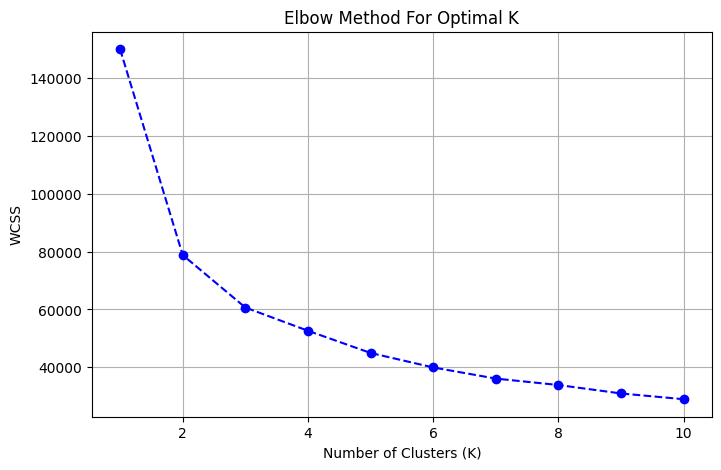

In [ ]:
# Calculate WCSS (Within-Cluster Sum of Square) for different K values
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [ ]:
# Fit the final model with 3 clusters
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)

# Add the cluster labels directly back into your original dataframe
df['Cluster'] = kmeans.fit_predict(X_scaled)

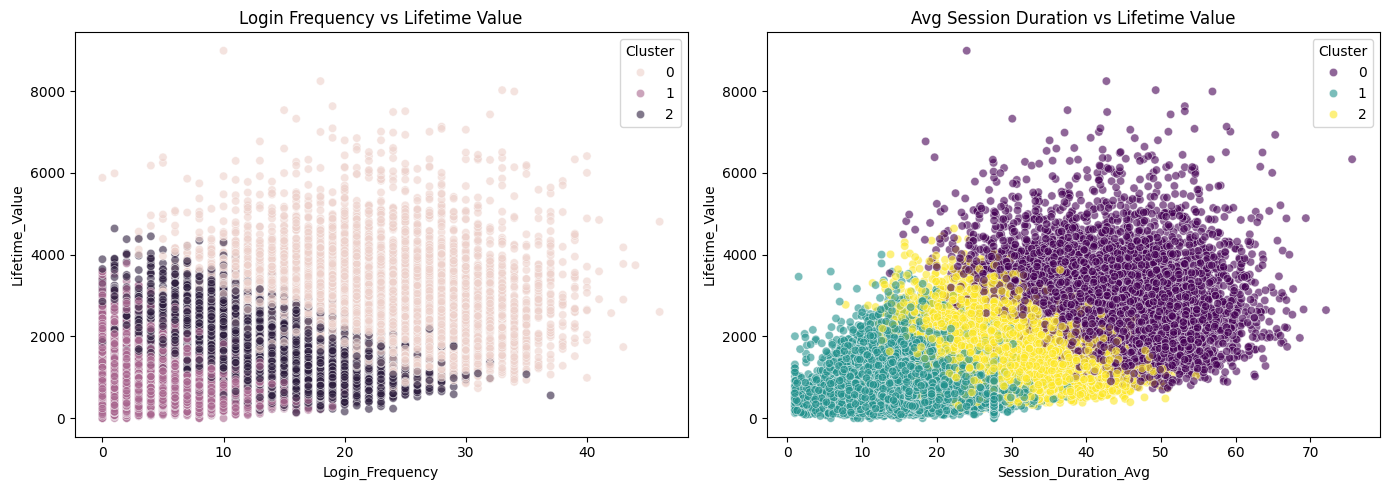

In [ ]:
plt.figure(figsize=(14, 5))

# Plot 1: Login Frequency vs Lifetime Value
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='Login_Frequency', y='Lifetime_Value', hue='Cluster',  alpha=0.6)
plt.title('Login Frequency vs Lifetime Value')

# Plot 2: Avg Session Duration vs Lifetime Value
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Session_Duration_Avg', y='Lifetime_Value', hue='Cluster', palette='viridis', alpha=0.6)
plt.title('Avg Session Duration vs Lifetime Value')

plt.tight_layout()
plt.show()


Cluster Profiles (Mean values):


,Lifetime_Value,Login_Frequency,Session_Duration_Avg
Cluster,,,
0,2704.00,22.21,42.28
1,857.34,5.17,19.36
2,1502.06,13.80,30.01


/tmp/ipykernel_1778/1429174996.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Cluster', palette='viridis')


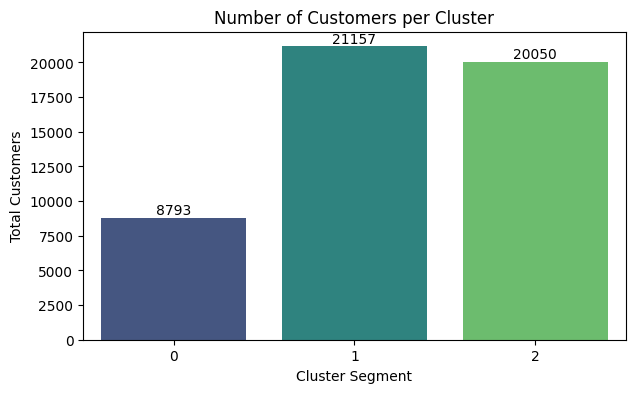

In [ ]:
# 5. Profile each cluster: Calculate mean values
cluster_profile = df.groupby('Cluster')[feature].mean().round(2)
print("Cluster Profiles (Mean values):")
display(cluster_profile)

# 6. Bar chart: number of customers per cluster
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df, x='Cluster', palette='viridis')
plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster Segment')
plt.ylabel('Total Customers')

# Add exact numbers on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

The highest customer value is occupied by cluster 1 hence
Cluster 1 (e.g., Low Value, Low Frequency): The "At-Risk/Window Shoppers"

**Profile: They rarely log in, spend less time per session, and generate the lowest revenue.**

**Marketing Action: Implement re-engagement campaigns. Send "We miss you" emails with steep, limited-time discount codes to incentivize a return purchase and build a habit.**